# Whorlmap Algorithm — Explanation Panels

Panels A–D illustrating how the whorl cell encodes a bootstrap distribution.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
from scipy.stats import gaussian_kde, norm
import dabest
from dabest.multi import combine, whorlmap

plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10})

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 46.92it/s]

Numba compilation complete!


## Helper functions

Exact reimplementation of dabest's internal spiral logic, so each panel can be built
without importing private functions.

In [2]:
def _spiralize(fill, m, n):
    """Outside-in rectangular spiral: top row right, right col down,
    bottom row left, left col up, then shrinks inward."""
    i = 0; j = 0; k = 0
    array = np.zeros((m, n))
    while m > 0 and k < len(fill):
        jj = j; ii = i
        for j in range(j, n):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        for i in range(ii + 1, m):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        for j in range(n - 2, jj - 1, -1):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        for i in range(m - 2, ii, -1):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        m -= 1; n -= 1; j += 1
    return array


def make_cell(bootstrap, n=21, chop_tail=2.5, reverse_neg=True):
    """Full pipeline: raw bootstrap array -> n x n spiral cell."""
    bs = sorted(bootstrap)
    chop = int(np.ceil(len(bs) * chop_tail / 100))
    if chop > 0:
        bs = bs[chop:-chop]
    ranks = np.linspace(0, len(bs), n * n, dtype=int)
    ranks[0] = 1
    if sum(v > 0 for v in bs) < len(bs) / 2 and reverse_neg:
        bs = bs[::-1]
    fill = [bs[r - 1] for r in ranks]
    return _spiralize(fill, n, n)


VLAG  = plt.get_cmap('vlag')
DNORM = TwoSlopeNorm(vcenter=0, vmin=-3.5, vmax=3.5)

## Panel A — Spiral traversal schematic

**Left**: 7×7 grid coloured by traversal order (purple = position 0, outer corner;
yellow = position 48, centre).  
**Right**: the bootstrap distribution being filled; each dot is one cell, coloured
by its spiral position.

/var/folders/jq/z93pq6zd39s_vky_yyjtcxp00000gn/T/ipykernel_71050/2430201579.py:82: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax_dist.plot(val, float(kde(val)), 'o',
/var/folders/jq/z93pq6zd39s_vky_yyjtcxp00000gn/T/ipykernel_71050/2430201579.py:91: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yv  = float(kde(val))


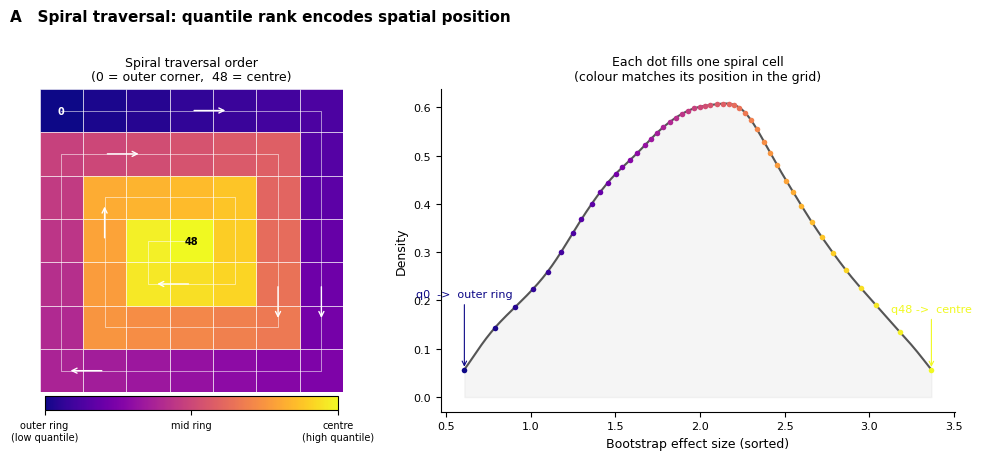

In [3]:
fig, (ax_grid, ax_dist) = plt.subplots(
    1, 2, figsize=(10, 4.5),
    gridspec_kw={'width_ratios': [1, 1.4]}
)

S = 7
N = S * S  # 49 cells

# position -> (row, col)
pos_grid = _spiralize(list(range(N)), S, S).astype(int)
pos_to_rc = {pos_grid[r, c]: (r, c) for r in range(S) for c in range(S)}

cmap_order = plt.get_cmap('plasma')
norm_order = Normalize(vmin=0, vmax=N - 1)

# colour each cell by its traversal position
for pos in range(N):
    r, c = pos_to_rc[pos]
    ax_grid.add_patch(Rectangle(
        (c, S - 1 - r), 1, 1,
        facecolor=cmap_order(norm_order(pos)),
        edgecolor='white', linewidth=0.4
    ))

# spiral path
px = [pos_to_rc[p][1] + 0.5 for p in range(N)]
py = [S - 0.5 - pos_to_rc[p][0] for p in range(N)]
ax_grid.plot(px, py, color='white', lw=0.7, alpha=0.55, zorder=5)

# directional arrows every 7 steps
for step in range(3, N - 1, 7):
    dx = px[step + 1] - px[step]
    dy = py[step + 1] - py[step]
    ax_grid.annotate(
        '', xy=(px[step] + dx * 0.85, py[step] + dy * 0.85),
        xytext=(px[step], py[step]),
        arrowprops=dict(arrowstyle='->', color='white', lw=1.0), zorder=7
    )

# label start and end
r0, c0 = pos_to_rc[0]
rN, cN = pos_to_rc[N - 1]
ax_grid.text(c0 + 0.5, S - 0.5 - r0, '0',
             ha='center', va='center', fontsize=7,
             color='white', fontweight='bold', zorder=8)
ax_grid.text(cN + 0.5, S - 0.5 - rN, str(N - 1),
             ha='center', va='center', fontsize=7,
             color='black', fontweight='bold', zorder=8)

ax_grid.set_xlim(0, S); ax_grid.set_ylim(0, S)
ax_grid.set_aspect('equal'); ax_grid.axis('off')
ax_grid.set_title(
    'Spiral traversal order\n(0 = outer corner,  48 = centre)',
    fontsize=9, pad=6
)

sm = ScalarMappable(cmap=cmap_order, norm=norm_order)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_grid, orientation='horizontal',
                    fraction=0.05, pad=0.01, shrink=0.8)
cbar.set_ticks([0, N // 2, N - 1])
cbar.set_ticklabels(['outer ring\n(low quantile)', 'mid ring', 'centre\n(high quantile)'])
cbar.ax.tick_params(labelsize=7)

# --- bootstrap distribution (right panel) ---
rng = np.random.default_rng(42)
bs  = sorted(rng.normal(2.0, 0.7, 5000))
chop = int(np.ceil(len(bs) * 0.025))
bs   = bs[chop:-chop]

ranks   = np.linspace(0, len(bs), N, dtype=int)
ranks[0] = 1
sampled  = [bs[r - 1] for r in ranks]

kde = gaussian_kde(bs)
xr  = np.linspace(bs[0], bs[-1], 300)
yr  = kde(xr)
ax_dist.fill_between(xr, yr, alpha=0.08, color='#888888')
ax_dist.plot(xr, yr, color='#555555', lw=1.5)

for pos, val in enumerate(sampled):
    ax_dist.plot(val, float(kde(val)), 'o',
                 color=cmap_order(norm_order(pos)),
                 ms=4, zorder=5, mew=0)

for pos, label, dy in [
    (0,     'q0  ->  outer ring', 0.15),
    (N - 1, 'q48 ->  centre',    0.12)
]:
    val = sampled[pos]
    yv  = float(kde(val))
    col = cmap_order(norm_order(pos))
    ax_dist.annotate(
        label, xy=(val, yv), xytext=(val, yv + dy),
        ha='center', fontsize=8, color=col,
        arrowprops=dict(arrowstyle='->', color=col, lw=0.8)
    )

ax_dist.set_xlabel('Bootstrap effect size (sorted)', fontsize=9)
ax_dist.set_ylabel('Density', fontsize=9)
ax_dist.set_title(
    'Each dot fills one spiral cell\n(colour matches its position in the grid)',
    fontsize=9, pad=6
)
ax_dist.spines[['top', 'right']].set_visible(False)
ax_dist.tick_params(labelsize=8)

plt.suptitle(
    'A   Spiral traversal: quantile rank encodes spatial position',
    fontsize=11, fontweight='bold', x=0.02, ha='left', y=1.01
)
plt.tight_layout()
plt.show()

## Panel B — 3D unit cell schematic

The whorl cell occupies the floor (z = 0).  The bootstrap distribution rises as a
coloured wall at the far edge (x = n).  Both surfaces share the same colour scale,
making the projection explicit.

/var/folders/jq/z93pq6zd39s_vky_yyjtcxp00000gn/T/ipykernel_71050/926999460.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


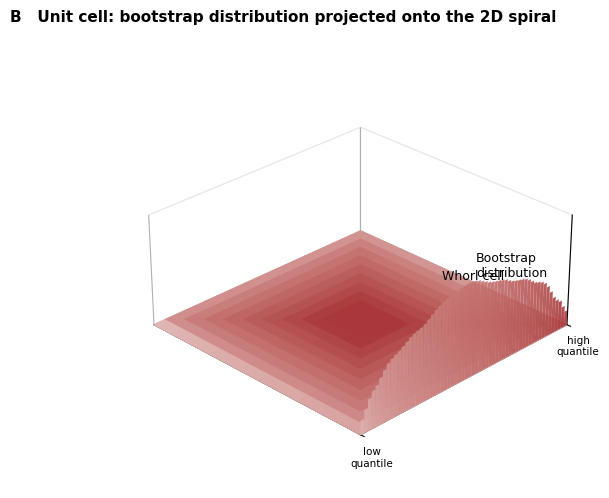

In [4]:
fig = plt.figure(figsize=(7, 5.5))
ax  = fig.add_subplot(111, projection='3d')

rng    = np.random.default_rng(7)
n      = 21
bs_raw = rng.normal(2.5, 0.65, 5000)
cell   = make_cell(bs_raw, n=n)

# ---- cell floor at z = 0 ------------------------------------------------
fc = VLAG(DNORM(np.clip(cell, -3.5, 3.5)))   # (n, n, 4)
Xg = np.arange(n + 1)
Yg = np.arange(n + 1)
Xm, Ym = np.meshgrid(Xg, Yg)
Zm = np.zeros_like(Xm, dtype=float)
ax.plot_surface(Xm, Ym, Zm, facecolors=fc, shade=False, rstride=1, cstride=1)

# ---- distribution wall at x = n -----------------------------------------
bs   = sorted(bs_raw)
chop = int(np.ceil(len(bs) * 0.025))
bs   = bs[chop:-chop]
kde  = gaussian_kde(bs, bw_method=0.12)

n_strips  = 60
y_edges   = np.linspace(0, n, n_strips + 1)
y_mids    = 0.5 * (y_edges[:-1] + y_edges[1:])
q_pos     = y_mids / n
q_vals    = np.quantile(bs, q_pos)
densities = kde(q_vals)
z_scale   = 8.0 / densities.max()

verts   = []
fcolors = []
for k in range(n_strips):
    y0, y1 = y_edges[k], y_edges[k + 1]
    zh = densities[k] * z_scale
    verts.append([(n, y0, 0), (n, y1, 0), (n, y1, zh), (n, y0, zh)])
    fcolors.append(VLAG(DNORM(np.clip(q_vals[k], -3.5, 3.5))))

wall = Poly3DCollection(verts, facecolors=fcolors, edgecolors='none', alpha=0.88)
ax.add_collection3d(wall)

# ---- style --------------------------------------------------------------
ax.set_xlim(0, n); ax.set_ylim(0, n); ax.set_zlim(0, 9.5)
ax.set_box_aspect([1, 1, 0.42])
ax.view_init(elev=28, azim=-45)

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('lightgray')
ax.grid(True, alpha=0.15)
ax.set_xticks([])
ax.set_yticks([0, n])
ax.set_yticklabels(['low\nquantile', 'high\nquantile'], fontsize=7.5)
ax.set_zticks([])
ax.tick_params(axis='y', pad=0)

ax.text(n / 2, n + 1.5, 0,
        'Whorl cell', ha='center', va='top', fontsize=9)
ax.text(n + 0.5, n / 2, densities.max() * z_scale + 0.5,
        'Bootstrap\ndistribution', ha='left', va='bottom', fontsize=9)

plt.suptitle(
    'B   Unit cell: bootstrap distribution projected onto the 2D spiral',
    fontsize=11, fontweight='bold', x=0.02, ha='left', y=0.98
)
plt.tight_layout()
plt.show()

## Panel C — Cell taxonomy

Five canonical distribution shapes and the whorl cells they produce.
All cells share the same colour scale (vlag, ±3.5).

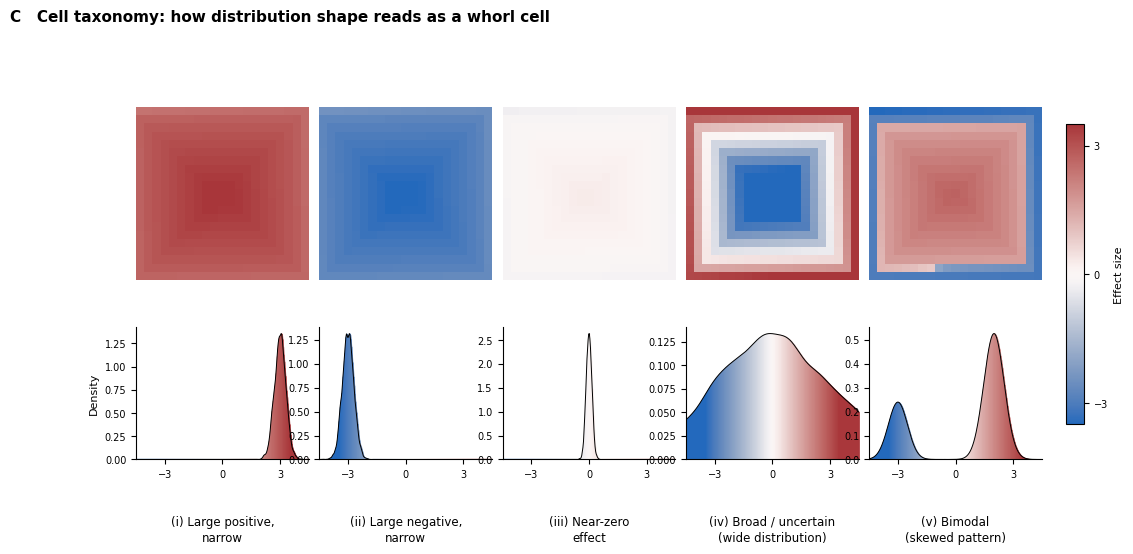

In [5]:
scenarios = [
    ('(i) Large positive,\nnarrow',
     np.random.default_rng(11).normal(3.0, 0.3, 5000)),
    ('(ii) Large negative,\nnarrow',
     np.random.default_rng(22).normal(-3.0, 0.3, 5000)),
    ('(iii) Near-zero\neffect',
     np.random.default_rng(33).normal(0.0, 0.15, 5000)),
    ('(iv) Broad / uncertain\n(wide distribution)',
     np.random.default_rng(44).normal(0.0, 3.0, 5000)),
    ('(v) Bimodal\n(skewed pattern)',
     np.concatenate([
         np.random.default_rng(55).normal(-3.0, 0.35, 1500),
         np.random.default_rng(66).normal( 2.0, 0.40, 3500),
     ])),
]

fig, axes = plt.subplots(
    2, 5, figsize=(12, 5),
    gridspec_kw={'hspace': 0.08, 'wspace': 0.06, 'height_ratios': [1.8, 1]}
)

for j, (label, bs_raw) in enumerate(scenarios):
    # top row: whorl cell
    cell = make_cell(bs_raw, n=21)
    axes[0, j].imshow(cell, cmap=VLAG, norm=DNORM,
                      interpolation='nearest', aspect='equal')
    axes[0, j].axis('off')

    # bottom row: KDE coloured by value
    bs  = sorted(bs_raw)
    kde = gaussian_kde(bs, bw_method=0.15)
    xr  = np.linspace(-4.5, 4.5, 300)
    yr  = kde(xr)
    col_strip = VLAG(DNORM(np.clip(xr, -3.5, 3.5)))
    for k in range(len(xr) - 1):
        axes[1, j].fill_between(
            [xr[k], xr[k + 1]], [yr[k], yr[k + 1]],
            alpha=0.8, color=col_strip[k]
        )
    axes[1, j].plot(xr, yr, 'k-', lw=0.7)
    axes[1, j].set_xlim(-4.5, 4.5)
    axes[1, j].set_ylim(bottom=0)
    axes[1, j].set_xticks([-3, 0, 3])
    axes[1, j].tick_params(labelsize=7)
    if j == 0:
        axes[1, j].set_ylabel('Density', fontsize=8)
    axes[1, j].spines[['top', 'right']].set_visible(False)
    axes[1, j].text(
        0.5, -0.42, label,
        transform=axes[1, j].transAxes,
        ha='center', fontsize=8.5, va='top', linespacing=1.3
    )

# shared colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.18, 0.015, 0.60])
sm = ScalarMappable(cmap=VLAG, norm=DNORM)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Effect size', fontsize=8)
cbar.set_ticks([-3, 0, 3])
cbar.ax.tick_params(labelsize=7)

plt.suptitle(
    'C   Cell taxonomy: how distribution shape reads as a whorl cell',
    fontsize=11, fontweight='bold', x=0.02, ha='left', y=1.01
)
plt.show()

## Panel D — Real whorlmap vs. scalar heatmap

Simulated transcriptomics data: 6 drugs × 8 transcripts, delta-delta design.
The whorlmap (left) preserves the full bootstrap distribution per cell;
the scalar mean heatmap (right) collapses each to a single number.

In [6]:
def create_delta_dataset(
    N=50, seed=9999,
    second_quarter_adjustment=3,
    third_quarter_adjustment=-0.5,
    fourth_quarter_adjustment=-3,
    scale4=1, initial_loc=10
):
    np.random.seed(seed)
    y = norm.rvs(loc=initial_loc, scale=0.4, size=N * 4)
    y[N:2*N]   = norm.rvs(loc=initial_loc + second_quarter_adjustment, scale=1,      size=N)
    y[2*N:3*N] = norm.rvs(loc=initial_loc + third_quarter_adjustment,  scale=0.4,    size=N)
    y[3*N:4*N] = norm.rvs(loc=initial_loc + fourth_quarter_adjustment, scale=scale4, size=N)
    return pd.DataFrame({
        'ID':               list(range(N * 2)) * 2,
        'Genotype':         np.repeat(['W', 'M', 'W', 'M'], N).tolist(),
        'Treatment':        np.repeat(['Placebo', 'Drug'], N * 2).tolist(),
        'Transcript Level': y,
    })


labels_2d     = [f'Transcript {i}' for i in range(1, 9)]
row_labels_2d = ['Drug A', 'Drug B', 'Drug C', 'Drug D', 'Drug E', 'Drug F']

drug_effect = [
    [ .9,  2.0,  2.0,  .5,  1.2,  1.0,  3.0, 2.0],
    [ .1,  -.3,   .1, -.3, -2.0,  1.2,  1.0,  .1],
    [4.0,  4.0,  1.0, 5.0,  1.0,  3.0,  6.5,  .5],
    [6.0,  2.0,  2.0, 4.0,  1.4,  -.5,  -.5, 1.1],
    [ .1,  -.3,   .1, -.3, -2.0,  1.2,  1.0,  .1],
    [-.3, -1.0,  2.0, 7.0,  1.0,  -.5,  4.0, 1.0],
]
drug_scale = [
    [ 5, 10,  1,  5,  1,  2,  1, 1],
    [ 7,  .2, 8,  3,  1,  4,  7, 1],
    [15,  3,  1,  2,  1,  1, 11, 1],
    [ 8,  .1, 1,  5,  1,  6,  1, 1],
    [ 9, 10,  7, 12,  4,  2, 14, 10],
    [ 4,  3,  1,  4,  1,  4,  4,  1],
]
seeds = [1, 1000, 20, 9999, 1000, 5320]

dabest_objects_2d = [[None] * 8 for _ in range(6)]
for i in range(6):
    for j in range(8):
        df = create_delta_dataset(
            seed=seeds[i],
            fourth_quarter_adjustment=drug_effect[i][j],
            scale4=drug_scale[i][j],
            initial_loc=20
        )
        dabest_objects_2d[i][j] = dabest.load(
            data=df,
            x=['Genotype', 'Genotype'],
            y='Transcript Level',
            delta2=True,
            experiment='Treatment'
        )

multi_2d = combine(dabest_objects_2d, labels_2d,
                   row_labels=row_labels_2d, effect_size='mean_diff')
print(multi_2d)

MultiContrast(2D: 6x8, effect_size='mean_diff', contrast_type='delta2')


TypeError: whorlmap() got an unexpected keyword argument 'title'

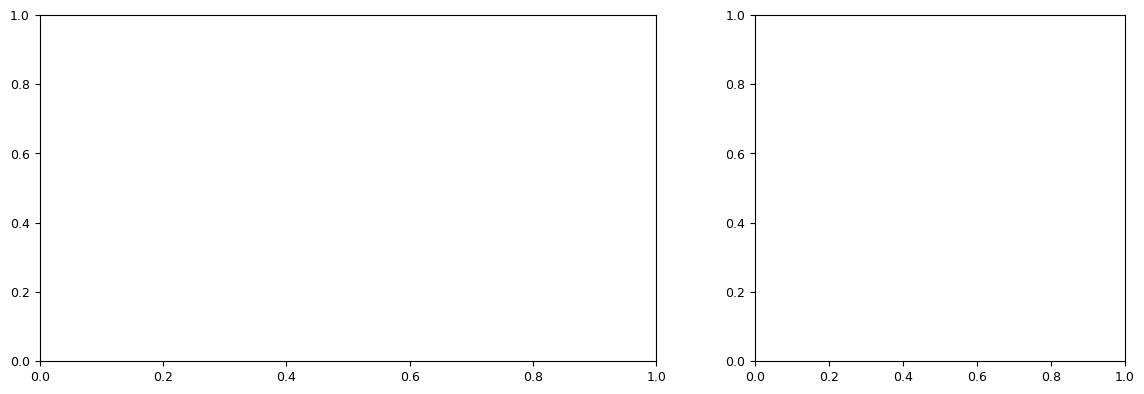

In [7]:
fig, (ax_whorl, ax_scalar) = plt.subplots(
    1, 2, figsize=(14, 4.5),
    gridspec_kw={'width_ratios': [3, 1.8]}
)

_, mean_df = multi_2d.whorlmap(
    cmap='vlag', chop_tail=2.5,
    title='Whorlmap (full bootstrap distribution per cell)',
    ax=ax_whorl
)

sns.heatmap(
    mean_df, ax=ax_scalar,
    cmap='vlag', center=0,
    annot=True, fmt='.1f',
    linewidths=0.5, linecolor='white',
    annot_kws={'fontsize': 7},
    cbar_kws={'label': 'Mean effect size', 'shrink': 0.8}
)
ax_scalar.set_title('Scalar mean\n(distribution info lost)', fontsize=10)
ax_scalar.tick_params(axis='x', rotation=45, labelsize=8)
ax_scalar.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle(
    'D   Real data: whorlmap vs. scalar mean heatmap',
    fontsize=11, fontweight='bold', x=0.02, ha='left', y=1.01
)
plt.tight_layout()
plt.show()

In [8]:
"""
panel_D.py — Whorlmap vs scalar heatmap comparison figure
==========================================================
Reproduces Panel D of the Whorlmap application note.

Two modes:
  --mode sim    (default) GTEx v8–informed simulation, seed=42.
                Runs anywhere, no data download required.

  --mode gtex   Download GTEx v8 individual-level TPM matrix (~2 GB)
                and subject phenotype file. Computes real Female − Male
                mean differences per (brain region, gene) cell.

Usage:
  python panel_D.py              # simulation mode
  python panel_D.py --mode gtex  # real GTEx data

Output:
  panel_D_whorlmap.png
  panel_D_scalar.png
  panel_D_comparison.png   (side-by-side)

Dependencies:
  pip install dabest pandas numpy matplotlib seaborn
  (GTEx mode also needs: pip install tqdm)

Citation (GTEx data):
  The GTEx Consortium. Science 2020; doi:10.1126/science.aaz1776
  GTEx v8 data: https://gtexportal.org/home/downloads/adult-gtex
"""

import argparse
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import dabest
from dabest.multi import combine

warnings.filterwarnings("ignore")

# ── Configuration ─────────────────────────────────────────────────────────────

# GTEx v8 direct download URLs (no authentication required)
GTEX_TPM_URL = (
    "https://storage.googleapis.com/adult-gtex/bulk-gex/v8/rna-seq/"
    "GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz"
)
GTEX_ATTR_URL = (
    "https://storage.googleapis.com/gtex_analysis_v8/annotations/"
    "GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"
)
GTEX_PHENO_URL = (
    "https://storage.googleapis.com/gtex_analysis_v8/annotations/"
    "GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt"
)

# Brain regions to include (GTEx tissue site detail names)
BRAIN_REGIONS = {
    "Hypothalamus":      "Brain - Hypothalamus",
    "Amygdala":          "Brain - Amygdala",
    "Hippocampus":       "Brain - Hippocampus",
    "Ant. Cing. Cortex": "Brain - Anterior cingulate cortex (BA24)",
    "Frontal Cortex":    "Brain - Frontal Cortex (BA9)",
    "Cortex":            "Brain - Cortex",
    "Caudate":           "Brain - Caudate (basal ganglia)",
    "Putamen":           "Brain - Putamen (basal ganglia)",
    "Nucleus Accumbens": "Brain - Nucleus accumbens (basal ganglia)",
    "Cerebellum":        "Brain - Cerebellum",
    "Cerebellar Hemi.":  "Brain - Cerebellar Hemisphere",
    "Substantia Nigra":  "Brain - Substantia nigra",
    "Spinal Cord":       "Brain - Spinal cord (cervical c-1)",
}

# Genes of interest — HGNC symbols (also used as GENCODE gene names in GTEx)
GENES = [
    "ESR1",     # Estrogen receptor α — brain-specific positive control
    "XIST",     # X-inactivation — sex-chromosome anchor (F >> M)
    "RPS4Y1",   # Y-linked ribosomal protein — sex-chromosome anchor (M >> F)
    "KDM6A",    # X-linked escape demethylase — moderate F > M everywhere
    "DDX3Y",    # Y-linked DEAD-box helicase — moderate M > F everywhere
    "DRD2",     # Dopamine D2 receptor — striatal male > female
    "CRH",      # Corticotropin-releasing hormone — limbic female > male
    "MAOA",     # Monoamine oxidase A — broad, moderate female > male
    "OXTR",     # Oxytocin receptor — high variance, crossing zero
    "BDNF",     # Brain-derived neurotrophic factor — wide CI
    "HTR1A",    # Serotonin 5-HT1A receptor — slight negative, wide CI
    "NRXN3",    # Neurexin 3 — synaptic, very wide CI
]

# GTEx v8 approximate female/male sample sizes per brain region
# (used in simulation mode; in GTEx mode these are computed from data)
SIM_N = {
    "Hypothalamus":      (54, 116),
    "Amygdala":          (48, 104),
    "Hippocampus":       (62, 135),
    "Ant. Cing. Cortex": (46, 101),
    "Frontal Cortex":    (66, 143),
    "Cortex":            (81, 174),
    "Caudate":           (78, 168),
    "Putamen":           (65, 140),
    "Nucleus Accumbens": (78, 168),
    "Cerebellum":        (76, 165),
    "Cerebellar Hemi.":  (68, 147),
    "Substantia Nigra":  (36,  78),
    "Spinal Cord":       (40,  86),
}

# Simulation parameters: (base_effect, noise_f, noise_m, {region: delta})
# effect = base + delta.get(region, 0.0)
# Female expr ~ N(10 + effect, noise_f),  Male ~ N(10, noise_m)
# All values in log2(TPM + 1) units
SIM_GENE_SPECS = {
    "ESR1":   (0.0, 1.4, 1.4, {
                   "Hypothalamus":      3.8,
                   "Amygdala":          3.0,
                   "Hippocampus":       1.5,
                   "Ant. Cing. Cortex": 0.8,
                   "Frontal Cortex":    0.6,
                   "Cortex":            0.5,
               }),
    "XIST":   (5.2, 0.25, 0.10, {}),
    "RPS4Y1": (-5.0, 0.10, 0.25, {}),
    "KDM6A":  (0.8, 0.30, 0.30, {}),
    "DDX3Y":  (-3.8, 0.15, 0.30, {}),
    "DRD2":   (0.0, 2.0, 2.0, {
                   "Caudate":           -2.5,
                   "Putamen":           -2.3,
                   "Nucleus Accumbens": -2.0,
                   "Substantia Nigra":  -1.8,
                   "Hypothalamus":      -0.6,
               }),
    "CRH":    (0.0, 1.2, 1.2, {
                   "Hypothalamus": 2.2,
                   "Amygdala":     0.9,
                   "Hippocampus":  0.4,
               }),
    "MAOA":   (0.4, 1.5, 1.5, {
                   "Frontal Cortex":    0.7,
                   "Cortex":            0.5,
                   "Ant. Cing. Cortex": 0.6,
                   "Amygdala":          0.5,
               }),
    "OXTR":   (0.1, 4.0, 4.0, {
                   "Hypothalamus": 0.9,
                   "Amygdala":     0.7,
                   "Hippocampus":  0.5,
               }),
    "BDNF":   (0.3, 3.0, 3.0, {
                   "Hippocampus": 1.0,
                   "Amygdala":    0.6,
                   "Cortex":      0.4,
               }),
    "HTR1A":  (-0.3, 2.8, 2.8, {
                   "Hippocampus":    -0.8,
                   "Amygdala":       -0.5,
                   "Frontal Cortex": -0.4,
               }),
    "NRXN3":  (0.2, 3.5, 3.5, {
                   "Hippocampus": 0.5,
                   "Cortex":      0.3,
                   "Amygdala":    0.4,
               }),
}


# ── Simulation mode ───────────────────────────────────────────────────────────

def build_sim_grid(seed=42):
    """Build a 13×12 DABEST object grid using GTEx-informed simulation."""
    np.random.seed(seed)
    brain_names = list(SIM_N.keys())
    dabest_grid = []
    for tname in brain_names:
        nf, nm = SIM_N[tname]
        row = []
        for gname in GENES:
            base, sf, sm, mod = SIM_GENE_SPECS[gname]
            eff = base + mod.get(tname, 0.0)
            female = np.random.normal(10 + eff, sf, nf)
            male   = np.random.normal(10,        sm, nm)
            df = pd.DataFrame({
                "expr": np.concatenate([female, male]),
                "sex":  ["Female"] * nf + ["Male"] * nm,
            })
            row.append(dabest.load(df, x="sex", y="expr", idx=("Male", "Female")))
        dabest_grid.append(row)

    mean_mx = pd.DataFrame(index=brain_names, columns=GENES, dtype=float)
    for tname in brain_names:
        for gname in GENES:
            base, *_, mod = SIM_GENE_SPECS[gname]
            mean_mx.loc[tname, gname] = base + mod.get(tname, 0.0)

    multi = combine(dabest_grid, GENES, row_labels=brain_names,
                    effect_size="mean_diff")
    return multi, mean_mx, brain_names


# ── GTEx download mode ────────────────────────────────────────────────────────

def build_gtex_grid():
    """
    Download GTEx v8 data and build the 13×12 DABEST grid.
    Warning: the TPM file is ~2 GB compressed; initial download takes time.
    Subsequent runs use the cached local file.
    """
    import urllib.request, os, gzip, io
    try:
        from tqdm import tqdm
        _tqdm_available = True
    except ImportError:
        _tqdm_available = False

    # Download helper
    def _download(url, dest):
        if os.path.exists(dest):
            print(f"  Using cached {dest}")
            return
        print(f"  Downloading {url} ...")
        urllib.request.urlretrieve(url, dest)
        print(f"  Saved to {dest}")

    # Fetch subject phenotypes (sex per donor)
    _download(GTEX_PHENO_URL, "GTEx_SubjectPhenotypes.txt")
    pheno = pd.read_csv("GTEx_SubjectPhenotypes.txt", sep="\t")
    # SEX: 1 = Male, 2 = Female
    sex_map = pheno.set_index("SUBJID")["SEX"].map({1: "Male", 2: "Female"})

    # Fetch sample attributes (tissue per sample)
    _download(GTEX_ATTR_URL, "GTEx_SampleAttributes.txt")
    attr = pd.read_csv("GTEx_SampleAttributes.txt", sep="\t",
                       usecols=["SAMPID", "SMTSD"])
    # Donor ID is first two fields of sample ID (GTEX-XXXX)
    attr["SUBJID"] = attr["SAMPID"].str.extract(r"(GTEX-[^-]+)")
    attr["SEX"] = attr["SUBJID"].map(sex_map)

    # Fetch full TPM matrix (large file — streamed and filtered)
    _download(GTEX_TPM_URL, "GTEx_gene_tpm.gct.gz")

    print("  Loading TPM matrix (this may take several minutes) ...")
    target_tissues = set(BRAIN_REGIONS.values())
    tissue_samples = {
        label: attr.loc[attr["SMTSD"] == gtex_name, ["SAMPID", "SEX"]]
        for label, gtex_name in BRAIN_REGIONS.items()
    }

    # Read only the rows for genes of interest
    gene_data = {g: {} for g in GENES}   # {gene: {sample_id: tpm}}
    with gzip.open("GTEx_gene_tpm.gct.gz", "rt") as fh:
        fh.readline(); fh.readline()      # skip header rows
        header = fh.readline().rstrip().split("\t")
        sample_cols = header[2:]          # sample IDs start at column 2
        for line in fh:
            parts = line.rstrip().split("\t")
            gene_name = parts[1]
            if gene_name not in GENES:
                continue
            tpm_values = np.log2(np.array(parts[2:], dtype=float) + 1)
            gene_data[gene_name] = dict(zip(sample_cols, tpm_values))
            if all(gene_data[g] for g in GENES):
                break  # all genes found

    # Build DABEST objects
    brain_names = list(BRAIN_REGIONS.keys())
    dabest_grid = []
    mean_mx = pd.DataFrame(index=brain_names, columns=GENES, dtype=float)

    for tname in brain_names:
        sdf = tissue_samples[tname].dropna(subset=["SEX"])
        row = []
        for gname in GENES:
            gd = gene_data[gname]
            sdf["expr"] = sdf["SAMPID"].map(gd)
            sdf_clean = sdf.dropna(subset=["expr"])
            df = sdf_clean[["expr", "SEX"]].rename(columns={"SEX": "sex"})
            dobj = dabest.load(df, x="sex", y="expr", idx=("Male", "Female"))
            row.append(dobj)
            female_expr = df.loc[df["sex"] == "Female", "expr"]
            male_expr   = df.loc[df["sex"] == "Male",   "expr"]
            mean_mx.loc[tname, gname] = female_expr.mean() - male_expr.mean()
        dabest_grid.append(row)

    multi = combine(dabest_grid, GENES, row_labels=brain_names,
                    effect_size="mean_diff")
    return multi, mean_mx, brain_names


# ── Figure generation ─────────────────────────────────────────────────────────

def make_figure(multi, mean_mx, brain_names, mode):
    vabs = float(mean_mx.abs().max().max()) * 1.05

    # ── Standalone whorlmap ────────────────────────────────────────────────
    fig_w, ax_w = plt.subplots(figsize=(14, 6.5))
    multi.whorlmap(
        cmap="vlag",
        chop_tail=2.5,
        title=(
            "Brain sex differences — whorlmap  "
            f"({'GTEx v8' if mode == 'gtex' else 'GTEx v8–informed simulation, seed=42'})"
        ),
        ax=ax_w,
        heatmap_kwargs={
            "cbar_kws": {
                "pad": 0.02,
                "label": "mean diff (F−M, log₂TPM+1)",
            },
        },
    )
    plt.tight_layout()
    fig_w.savefig("panel_D_whorlmap.png", dpi=150, bbox_inches="tight")
    plt.close(fig_w)
    print("Saved: panel_D_whorlmap.png")

    # ── Standalone scalar heatmap ──────────────────────────────────────────
    fig_h, ax_h = plt.subplots(figsize=(14, 6.5))
    sns.heatmap(
        mean_mx.astype(float),
        cmap="vlag", center=0, vmin=-vabs, vmax=vabs, ax=ax_h,
        cbar_kws={"pad": 0.02, "label": "mean diff (F−M, log₂TPM+1)"},
    )
    ax_h.set_title("Scalar heatmap — mean effect only")
    plt.setp(ax_h.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    plt.setp(ax_h.get_yticklabels(), rotation=0,  fontsize=9)
    plt.tight_layout()
    fig_h.savefig("panel_D_scalar.png", dpi=150, bbox_inches="tight")
    plt.close(fig_h)
    print("Saved: panel_D_scalar.png")

    # ── Side-by-side comparison ────────────────────────────────────────────
    fig2 = plt.figure(figsize=(23, 8))
    gs   = gridspec.GridSpec(1, 2, figure=fig2, wspace=0.09, width_ratios=[1, 1])
    ax1  = fig2.add_subplot(gs[0])
    ax2  = fig2.add_subplot(gs[1])

    multi.whorlmap(
        cmap="vlag", chop_tail=2.5,
        title="Whorlmap — full bootstrap distribution per cell",
        ax=ax1,
        heatmap_kwargs={
            "cbar_kws": {"pad": 0.02, "label": "mean diff (F−M)"},
        },
    )

    sns.heatmap(
        mean_mx.astype(float),
        cmap="vlag", center=0, vmin=-vabs, vmax=vabs, ax=ax2,
        cbar_kws={"pad": 0.02, "label": "mean diff (F−M)"},
    )
    ax2.set_title("Scalar heatmap — mean only")
    plt.setp(ax2.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    plt.setp(ax2.get_yticklabels(), rotation=0,  fontsize=9)

    mode_label = (
        "GTEx v8" if mode == "gtex"
        else "GTEx v8–informed simulation, seed=42"
    )
    plt.suptitle(
        "Sex-biased gene expression across 13 human brain regions\n"
        f"Female − Male (log₂TPM+1)  |  {mode_label}",
        fontsize=11, y=1.01,
    )
    fig2.savefig("panel_D_comparison.png", dpi=150, bbox_inches="tight")
    plt.close(fig2)
    print("Saved: panel_D_comparison.png")


# ── Entry point ───────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description="Generate Panel D whorlmap")
    parser.add_argument(
        "--mode", choices=["sim", "gtex"], default="sim",
        help="sim = GTEx-informed simulation (default); gtex = download real data",
    )
    args = parser.parse_args()

    print(f"Mode: {args.mode}")

    if args.mode == "sim":
        print("Building simulation (seed=42) ...")
        multi, mean_mx, brain_names = build_sim_grid(seed=42)
    else:
        print("Fetching GTEx v8 data ...")
        multi, mean_mx, brain_names = build_gtex_grid()

    print("Rendering figures ...")
    make_figure(multi, mean_mx, brain_names, mode=args.mode)
    print("Done.")


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--mode {sim,gtex}]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/sangyuxu/Library/Jupyter/runtime/kernel-v352adeb6e8f9c53f151ab1930b0cf00fd9184b03f.json


SystemExit: 2